# 08｜Virtual Metrology — Group-Aware Predictive Modeling

## 這一本要回答的問題

07 已經把 Raw process trace 整理成 wafer-level features。

08 主要要做的是：

> **用 Process Features 預測每片 wafer 的 `mean_si_etch`。**

這裡不把同一個 Lot 的 wafers 隨機拆成 train / test，而是把 `lot_number` 當成 group，使用 **Leave-One-Lot-Out**。

也就是每一次都把一整個 Lot 留在外面測試。

這一版會保留原本的 **Process-only Virtual Metrology** 當主要模型，另外新增一個獨立的 **Process + Sequence ablation**。

所以最後會比較四個結果：

1. Training-Mean Baseline
2. Sequence-Only Baseline
3. Process-Only Nested Model
4. Process + Sequence Nested Ablation

`wafer_number` 不會放進正式 Process-only model，只會出現在 Baseline 和 Ablation 裡。

這一本只建立 `mean_si_etch` 模型。


## 1. Modeling 怎麼設計？

這裡使用兩層 group-aware validation。

### Outer loop：Leave-One-Lot-Out

每一次完整留一個 Lot 當 test。  
這個 test Lot 不會參與：

- near-constant feature filtering
- scaling
- feature-set selection
- hyperparameter selection
- model selection

### Inner loop：3-Fold GroupKFold

只在剩下的 outer-training Lots 裡比較 candidates。

這次測試的 model families 有：

- Ridge
- ElasticNet
- PLS Regression
- RBF-SVR

Feature sets 則比較：

- Base
- Extended

07 雖然有做 full-data near-constant diagnostic，但那只是觀察用。  
08 會在每一個 training fold 裡重新做：

`Fold-local Near-Constant Filter → StandardScaler → Model`

也就是所有需要 `fit()` 的 preprocessing 都只看 training data。

另外我保留兩個很簡單的 baseline：

1. Training-Mean baseline
2. Wafer-Sequence-Only linear baseline

第二個 baseline 故意只用 `wafer_number`，不是正式 deployment model，而是讓我知道：如果 process model 表現很好，它至少要和一個已知有很強 sequence structure 的簡單模型比較。


In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR


pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 200)

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

base_path = PROCESSED_DATA_DIR / "07_modeling_dataset_base.csv"
extended_path = PROCESSED_DATA_DIR / "07_modeling_dataset_extended.csv"

for path in [base_path, extended_path]:
    print(f"{path.name:<42}", "存在" if path.exists() else "找不到")

if not base_path.exists() or not extended_path.exists():
    raise FileNotFoundError("缺少 07 的 Modeling Dataset，請先完成 07_feature_engineering。")


class RelativeToleranceFeatureFilter(BaseEstimator, TransformerMixin):
    """Fold-local near-constant filter using np.allclose-like tolerance.

    A feature is removed when every training value is close to the first
    training value under: atol + rtol * |reference|.
    The held-out fold never participates in this decision.
    """

    def __init__(self, rtol=1e-7, atol=1e-8):
        self.rtol = rtol
        self.atol = atol

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)

        if X.ndim != 2:
            raise ValueError("X 必須是 2D matrix")
        if X.shape[0] == 0 or X.shape[1] == 0:
            raise ValueError("X 不可為空")
        if not np.isfinite(X).all():
            raise ValueError("Near-constant filter 收到 NaN / Inf")

        reference = X[0]
        tolerance = self.atol + self.rtol * np.abs(reference)
        max_deviation = np.max(np.abs(X - reference), axis=0)

        self.support_ = max_deviation > tolerance
        self.n_features_in_ = X.shape[1]

        if not self.support_.any():
            raise ValueError("Training fold 的所有 predictors 都被判定為 near-constant")

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return X[:, self.support_]

    def get_support(self, indices=False):
        if not hasattr(self, "support_"):
            raise ValueError("Filter 尚未 fit")
        if indices:
            return np.flatnonzero(self.support_)
        return self.support_.copy()


07_modeling_dataset_base.csv               存在
07_modeling_dataset_extended.csv           存在


### 1.1 這個輸出代表什麼？

這格顯示 08 需要的兩份資料都有找到：

- `07_modeling_dataset_base.csv`：**存在**
- `07_modeling_dataset_extended.csv`：**存在**

所以這一步沒有缺檔問題，可以繼續往下讀資料。


In [2]:
base_df = pd.read_csv(base_path)
extended_df = pd.read_csv(extended_path)

metadata_columns = [
    "experiment_key",
    "lot_number",
    "wafer_number",
]

target_columns = [
    "mean_si_etch",
    "cv_si_etch_pct",
    "std_si_etch",
    "range_si_etch",
    "p90_width_si_etch",
]

base_predictors = [
    column
    for column in base_df.columns
    if column not in metadata_columns + target_columns
]

extended_predictors = [
    column
    for column in extended_df.columns
    if column not in metadata_columns + target_columns
]

if not base_df[metadata_columns].equals(extended_df[metadata_columns]):
    raise ValueError("Base / Extended 的 Wafer Metadata 順序不一致")

if not np.allclose(base_df["mean_si_etch"], extended_df["mean_si_etch"]):
    raise ValueError("Base / Extended 的 Target 不一致")

if base_df["experiment_key"].duplicated().any():
    raise ValueError("Base Dataset 出現重複 experiment_key")

if extended_df["experiment_key"].duplicated().any():
    raise ValueError("Extended Dataset 出現重複 experiment_key")

assert len(base_df) == 88
assert len(extended_df) == 88
assert base_df["lot_number"].nunique() == 10
assert len(base_predictors) == 82
assert len(extended_predictors) == 109
assert not base_df[base_predictors].isna().any().any()
assert not extended_df[extended_predictors].isna().any().any()
assert not base_df["mean_si_etch"].isna().any()

print("Labeled Wafers：", len(base_df))
print("Lots：", base_df["lot_number"].nunique())
print("Base Predictors：", len(base_predictors))
print("Extended Predictors：", len(extended_predictors))
print("Base Missing：", int(base_df[base_predictors].isna().sum().sum()))
print("Extended Missing：", int(extended_df[extended_predictors].isna().sum().sum()))
print("Target Missing：", int(base_df["mean_si_etch"].isna().sum()))

print("\nLabeled Wafers by Lot：")
display(
    base_df.groupby("lot_number").size().rename("n_wafers").reset_index()
)

print("\nMean Si Etch Summary：")
display(base_df["mean_si_etch"].describe())


Labeled Wafers： 88
Lots： 10
Base Predictors： 82
Extended Predictors： 109
Base Missing： 0
Extended Missing： 0
Target Missing： 0

Labeled Wafers by Lot：


,lot_number,n_wafers
0,1,9
1,2,10
2,3,10
3,4,10
4,5,10
5,6,10
6,7,6
7,8,10
8,9,9
9,10,4



Mean Si Etch Summary：


count    88.000000
mean     43.668120
std       0.401909
min      42.942928
25%      43.349077
50%      43.667601
75%      43.983902
max      44.376304
Name: mean_si_etch, dtype: float64

### 2.1 這個輸出代表什麼？

這格實際讀到：

- Labeled Wafers：**88**
- Lots：**10**
- Base Predictors：**82**
- Extended Predictors：**109**
- Base Missing：**0**
- Extended Missing：**0**
- Target Missing：**0**

每個 Lot 的樣本數不完全一樣。Lot 2～6、8 都有 **10 片**，Lot 1 和 Lot 9 各 **9 片**，Lot 7 有 **6 片**，Lot 10 最少，只有 **4 片**。

`mean_si_etch` 的分布是：

- 平均值：**43.6681**
- 標準差：**0.4019**
- 最小值：**42.9429**
- 中位數：**43.6676**
- 最大值：**44.3763**

最大值和最小值相差大約 **1.4334 µm**。

所以這格主要是在確認：88 片 labeled wafers 沒有 predictor 或 target missing，而且不同 Lot 的樣本數有差。


## 3. 建立 X / y / groups，先做欄位層級的 Leakage Check

正式 process model 不放：

- `lot_number`
- `wafer_number`
- `experiment_key`
- Quality target

其中：

- `lot_number` 只拿來分 group；
- `wafer_number` 只用在 sequence-only baseline；
- 正式 model 只吃 07 定義的 process predictors。

這一步先檢查欄位名稱，確認最直接的 target / ID leakage 沒有混進來。


In [3]:
X_sets = {
    "Base": base_df[base_predictors].to_numpy(dtype=float),
    "Extended": extended_df[extended_predictors].to_numpy(dtype=float),
}

predictor_names = {
    "Base": base_predictors,
    "Extended": extended_predictors,
}

y = base_df["mean_si_etch"].to_numpy(dtype=float)
groups = base_df["lot_number"].to_numpy(dtype=int)
wafer_number = base_df["wafer_number"].to_numpy(dtype=float)
experiment_keys = base_df["experiment_key"].to_numpy()

forbidden = {
    "experiment_key",
    "lot_number",
    "wafer_number",
    "mean_si_etch",
    "cv_si_etch_pct",
    "std_si_etch",
    "range_si_etch",
    "p90_width_si_etch",
}

for name, columns in predictor_names.items():
    overlap = sorted(set(columns) & forbidden)
    print(name, "Forbidden Overlap：", overlap)
    assert len(overlap) == 0

print("Group Count：", len(np.unique(groups)))
print("Column-Level Leakage Guard：通過")


Base Forbidden Overlap： []
Extended Forbidden Overlap： []
Group Count： 10
Column-Level Leakage Guard：通過


### 3.1 這個輸出代表什麼？

這格的結果是：

- Base Forbidden Overlap：`[]`
- Extended Forbidden Overlap：`[]`
- Group Count：**10**
- Column-Level Leakage Guard：**通過**

也就是 Base 和 Extended predictors 裡，都沒有直接出現這裡設定成禁止使用的欄位。

同時 `lot_number` 一共有 **10 個 groups**，和前面資料中的 10 個 Lots 一致。


## 4. 先建立兩個簡單 Baselines

在看比較複雜的 model 前，先用兩個很簡單的方法當參考。

### Training-Mean Baseline

每個 held-out Lot 都只預測 outer-training wafers 的平均 `mean_si_etch`。

這可以看成「完全不知道 process，只猜 training 平均」。

### Sequence-Only Baseline

只用 `wafer_number` 建 linear regression，而且每個 outer fold 都只用 training Lots fit。

這不是正式 process model。  
它只是讓我知道，單靠 wafer sequence 這個很簡單的資訊，本身已經能做到什麼程度。


In [4]:
outer_cv = LeaveOneGroupOut()
outer_splits = list(outer_cv.split(np.zeros(len(y)), y, groups))

mean_baseline_pred = np.full(len(y), np.nan)
sequence_baseline_pred = np.full(len(y), np.nan)

for train_idx, test_idx in outer_splits:
    y_train = y[train_idx]

    mean_baseline_pred[test_idx] = y_train.mean()

    sequence_model = LinearRegression()
    sequence_model.fit(
        wafer_number[train_idx].reshape(-1, 1),
        y_train,
    )
    sequence_baseline_pred[test_idx] = sequence_model.predict(
        wafer_number[test_idx].reshape(-1, 1)
    )


def regression_metrics(actual, predicted):
    return {
        "rmse": float(mean_squared_error(actual, predicted) ** 0.5),
        "mae": float(mean_absolute_error(actual, predicted)),
        "r2": float(r2_score(actual, predicted)),
    }

baseline_metrics = pd.DataFrame(
    [
        {"model": "Training-Mean Baseline", **regression_metrics(y, mean_baseline_pred)},
        {"model": "Sequence-Only Linear Baseline", **regression_metrics(y, sequence_baseline_pred)},
    ]
)

display(baseline_metrics.round(4))


,model,rmse,mae,r2
0,Training-Mean Baseline,0.4044,0.3477,-0.0239
1,Sequence-Only Linear Baseline,0.2209,0.1833,0.6944


### 4.1 這個輸出代表什麼？

兩個 baseline 的結果是：

**Training-Mean Baseline**

- RMSE：**0.4044**
- MAE：**0.3477**
- R²：**-0.0239**

**Sequence-Only Linear Baseline**

- RMSE：**0.2209**
- MAE：**0.1833**
- R²：**0.6944**

直接比較可以看到，Sequence-Only 的 RMSE 從 **0.4044 降到 0.2209**，大約低 **45.4%**。

MAE 也從 **0.3477 降到 0.1833**，而 R² 從負值變成 **0.6944**。

所以單看這個輸出，`wafer_number` 這一個 sequence 變數就已經比只猜 training mean 的 baseline 表現好很多。


## 5. 建立 Candidate Pipelines

因為只有 88 片 labeled wafers，我沒有做超大的 hyperparameter search，而是保留幾個比較合理的候選。

### Ridge

適合很多相關 predictors，用 L2 regularization 控制 coefficient。

### ElasticNet

同時有 L1 + L2，除了 regularization，也能把一部分 coefficients 壓到 0。

### PLS Regression

把 predictors 壓成 supervised latent components，常用在小樣本、高共線性的 regression。

### RBF-SVR

保留一個 nonlinear candidate，看看 nonlinear relationship 有沒有明顯優勢。

每個 model 前面都會先跑：

`RelativeToleranceFeatureFilter → StandardScaler`

而且這兩步都在 training fold 裡重新 fit。


In [5]:
def build_estimator(model_name, params):
    preprocessing = [
        ("variance", RelativeToleranceFeatureFilter(rtol=1e-7, atol=1e-8)),
        ("scale", StandardScaler()),
    ]

    if model_name == "Ridge":
        model = Ridge(alpha=params["alpha"])

    elif model_name == "ElasticNet":
        model = ElasticNet(
            alpha=params["alpha"],
            l1_ratio=params["l1_ratio"],
            max_iter=20_000,
            tol=1e-4,
            random_state=42,
        )

    elif model_name == "PLS":
        model = PLSRegression(
            n_components=params["n_components"],
            scale=False,
            max_iter=500,
        )

    elif model_name == "SVR":
        model = SVR(
            kernel="rbf",
            C=params["C"],
            gamma=params["gamma"],
            epsilon=0.05,
        )

    else:
        raise ValueError(f"未知模型：{model_name}")

    return Pipeline(preprocessing + [("model", model)])


candidate_configs = []

for feature_set in ["Base", "Extended"]:
    for alpha in [0.1, 1, 10, 100]:
        candidate_configs.append(
            (feature_set, "Ridge", {"alpha": alpha})
        )

    for alpha in [0.01, 0.1]:
        for l1_ratio in [0.1, 0.5, 0.9]:
            candidate_configs.append(
                (
                    feature_set,
                    "ElasticNet",
                    {"alpha": alpha, "l1_ratio": l1_ratio},
                )
            )

    for n_components in [2, 3, 5, 8]:
        candidate_configs.append(
            (
                feature_set,
                "PLS",
                {"n_components": n_components},
            )
        )

    for C in [1, 10]:
        for gamma in ["scale", 0.01]:
            candidate_configs.append(
                (
                    feature_set,
                    "SVR",
                    {"C": C, "gamma": gamma},
                )
            )

print("Candidate Configurations：", len(candidate_configs))

candidate_summary = (
    pd.DataFrame(
        [
            {"feature_set": fs, "model": model}
            for fs, model, _ in candidate_configs
        ]
    )
    .groupby(["feature_set", "model"])
    .size()
    .rename("n_configs")
    .reset_index()
)

display(candidate_summary)


Candidate Configurations： 36


,feature_set,model,n_configs
0,Base,ElasticNet,6
1,Base,PLS,4
2,Base,Ridge,4
3,Base,SVR,4
4,Extended,ElasticNet,6
5,Extended,PLS,4
6,Extended,Ridge,4
7,Extended,SVR,4


### 5.1 這個輸出代表什麼？

這格一共建立 **36 組 candidate configurations**。

Base 和 Extended 各有：

- ElasticNet：6 組
- PLS：4 組
- Ridge：4 組
- SVR：4 組

也就是：

- Base：**18 組**
- Extended：**18 組**

兩個 feature sets 的候選數量是一樣的。


## 6. Nested Leave-One-Lot-Out Evaluation

這是 08 最重要的一段。

每個 outer fold 都照同樣流程：

1. 留下一個完整 Lot 當 test；
2. 只在其他 Lots 裡做 3-fold `GroupKFold`；
3. 比較 36 組 candidates；
4. 用 inner pooled RMSE 選出這個 outer fold 的最佳設定；
5. 用全部 outer-training data 重新 fit；
6. 最後只預測那個完全沒參與 selection 的 held-out Lot。

10 個 Lots 都輪過一次後，就得到 88 片 wafers 的 nested OOF predictions。

這個結果才是這一本最主要的 internal generalization evidence。


In [6]:
def inner_group_oof_rmse(X_train, y_train, group_train, estimator):
    n_splits = min(3, len(np.unique(group_train)))
    inner_cv = GroupKFold(n_splits=n_splits)

    inner_pred = np.full(len(y_train), np.nan)

    for inner_train_idx, inner_valid_idx in inner_cv.split(
        X_train,
        y_train,
        group_train,
    ):
        fitted = clone(estimator)
        fitted.fit(
            X_train[inner_train_idx],
            y_train[inner_train_idx],
        )
        inner_pred[inner_valid_idx] = np.asarray(
            fitted.predict(X_train[inner_valid_idx])
        ).reshape(-1)

    return float(mean_squared_error(y_train, inner_pred) ** 0.5)


nested_oof_pred = np.full(len(y), np.nan)
inner_score_records = []
outer_fold_records = []

for outer_fold, (train_idx, test_idx) in enumerate(outer_splits, start=1):
    test_lot = int(np.unique(groups[test_idx])[0])

    y_train = y[train_idx]
    group_train = groups[train_idx]

    best_config = None

    for feature_set, model_name, params in candidate_configs:
        estimator = build_estimator(model_name, params)

        inner_rmse = inner_group_oof_rmse(
            X_sets[feature_set][train_idx],
            y_train,
            group_train,
            estimator,
        )

        inner_score_records.append(
            {
                "outer_fold": outer_fold,
                "test_lot": test_lot,
                "feature_set": feature_set,
                "model": model_name,
                "params": json.dumps(params, sort_keys=True),
                "inner_rmse": inner_rmse,
            }
        )

        if best_config is None or inner_rmse < best_config[0]:
            best_config = (
                inner_rmse,
                feature_set,
                model_name,
                params,
            )

    selected_inner_rmse, feature_set, model_name, params = best_config

    final_estimator = build_estimator(model_name, params)
    final_estimator.fit(
        X_sets[feature_set][train_idx],
        y_train,
    )

    fold_pred = np.asarray(
        final_estimator.predict(X_sets[feature_set][test_idx])
    ).reshape(-1)

    nested_oof_pred[test_idx] = fold_pred

    outer_fold_records.append(
        {
            "outer_fold": outer_fold,
            "test_lot": test_lot,
            "n_test": len(test_idx),
            "feature_set": feature_set,
            "model": model_name,
            "params": json.dumps(params, sort_keys=True),
            "inner_selected_rmse": selected_inner_rmse,
            "outer_rmse": float(mean_squared_error(y[test_idx], fold_pred) ** 0.5),
            "outer_mae": float(mean_absolute_error(y[test_idx], fold_pred)),
            "mean_baseline_rmse": float(
                mean_squared_error(y[test_idx], mean_baseline_pred[test_idx]) ** 0.5
            ),
            "sequence_baseline_rmse": float(
                mean_squared_error(y[test_idx], sequence_baseline_pred[test_idx]) ** 0.5
            ),
        }
    )

inner_candidate_scores = pd.DataFrame(inner_score_records)
outer_fold_results = pd.DataFrame(outer_fold_records)

nested_metrics = pd.DataFrame(
    [
        {
            "model": "Nested Model-Selection Procedure",
            **regression_metrics(y, nested_oof_pred),
        }
    ]
)

print("Nested OOF Performance：")
display(nested_metrics.round(4))

print("Outer Fold Results：")
display(
    outer_fold_results[
        [
            "test_lot",
            "n_test",
            "feature_set",
            "model",
            "params",
            "outer_rmse",
            "outer_mae",
            "mean_baseline_rmse",
            "sequence_baseline_rmse",
        ]
    ].round(4)
)


Nested OOF Performance：


,model,rmse,mae,r2
0,Nested Model-Selection Procedure,0.1296,0.0972,0.8948


Outer Fold Results：


,test_lot,n_test,feature_set,model,params,outer_rmse,outer_mae,mean_baseline_rmse,sequence_baseline_rmse
0,1,9,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.5}",0.0652,0.0551,0.4025,0.1679
1,2,10,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",0.1100,0.0963,0.4515,0.2043
2,3,10,Base,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",0.1430,0.1288,0.3912,0.2161
3,4,10,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.5}",0.1143,0.0983,0.5086,0.2676
4,5,10,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.5}",0.1377,0.1133,0.4212,0.2325
5,6,10,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",0.1175,0.0824,0.4143,0.2418
6,7,6,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.5}",0.1184,0.0934,0.2366,0.2084
7,8,10,Base,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.5}",0.2238,0.1476,0.2079,0.2363
8,9,9,Base,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",0.0698,0.0582,0.4231,0.2113
9,10,4,Base,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",0.0832,0.0775,0.4762,0.1540


### 6.1 這個輸出代表什麼？

Process-only Nested OOF 的整體結果是：

- RMSE：**0.1296**
- MAE：**0.0972**
- R²：**0.8948**

和前面的 baseline 比：

- Sequence-Only RMSE = **0.2209**
- Process-Only RMSE = **0.1296**

RMSE 大約再低 **41.3%**。

和 Training-Mean 的 **0.4044** 比，Process-Only RMSE 大約低 **68.0%**。

分 Lot 看：

- 最低 RMSE：Lot 1 = **0.0652**
- 最高 RMSE：Lot 8 = **0.2238**

Process-Only 在 **10/10 個 Lots** 的 RMSE 都低於 Sequence-Only。

和 Mean Baseline 比則是 **9/10 個 Lots** 比較低；唯一例外是 Lot 8：

- Process-Only：**0.2238**
- Mean Baseline：**0.2079**

所以這格的實際結果是：Process-only 整體表現比兩個 baseline 好，但各 Lot 的誤差差距不小，Lot 8 明顯比較高。


## 6.2 Process + Sequence Ablation

前面的正式 Process-only model 沒有使用 `wafer_number`。

但 04 已經看到 Quality 和一些 Process Signals 都有 wafer-sequence structure，所以這裡另外做一個獨立比較：

`Process Features + wafer_number`

這個 Ablation 使用和 Process-only 一樣的：

- Outer Leave-One-Lot-Out
- Inner GroupKFold
- 36 組 candidate configurations
- Fold-local Near-Constant Filter
- StandardScaler

差別只有 predictor matrix 多放一欄 `wafer_number`。

這一段不會取代正式 Process-only model，也不會改掉原本 `08_nested_oof_predictions.csv`。

它只另外回答：

> 加入 wafer sequence 後，held-out-Lot prediction 的數字會變成多少？


In [7]:
X_plus_sequence = {
    feature_set: np.column_stack(
        [
            X_sets[feature_set],
            wafer_number,
        ]
    )
    for feature_set in X_sets
}

process_plus_sequence_oof_pred = np.full(
    len(y),
    np.nan,
)

ablation_inner_score_records = []
ablation_outer_records = []

for outer_fold, (train_idx, test_idx) in enumerate(
    outer_splits,
    start=1,
):
    test_lot = int(
        np.unique(groups[test_idx])[0]
    )

    y_train = y[train_idx]
    group_train = groups[train_idx]

    best_config = None

    for feature_set, model_name, params in candidate_configs:
        estimator = build_estimator(
            model_name,
            params,
        )

        inner_rmse = inner_group_oof_rmse(
            X_plus_sequence[
                feature_set
            ][train_idx],
            y_train,
            group_train,
            estimator,
        )

        ablation_inner_score_records.append(
            {
                "outer_fold": outer_fold,
                "test_lot": test_lot,
                "feature_set": feature_set,
                "model": model_name,
                "params": json.dumps(
                    params,
                    sort_keys=True,
                ),
                "inner_rmse": inner_rmse,
            }
        )

        if (
            best_config is None
            or inner_rmse < best_config[0]
        ):
            best_config = (
                inner_rmse,
                feature_set,
                model_name,
                params,
            )

    (
        selected_inner_rmse,
        selected_feature_set,
        selected_model,
        selected_params,
    ) = best_config

    estimator = build_estimator(
        selected_model,
        selected_params,
    )

    estimator.fit(
        X_plus_sequence[
            selected_feature_set
        ][train_idx],
        y_train,
    )

    prediction = np.asarray(
        estimator.predict(
            X_plus_sequence[
                selected_feature_set
            ][test_idx]
        )
    ).reshape(-1)

    process_plus_sequence_oof_pred[
        test_idx
    ] = prediction

    ablation_outer_records.append(
        {
            "outer_fold": outer_fold,
            "test_lot": test_lot,
            "n_test": len(test_idx),
            "feature_set": selected_feature_set,
            "model": selected_model,
            "params": json.dumps(
                selected_params,
                sort_keys=True,
            ),
            "inner_selected_rmse": (
                selected_inner_rmse
            ),
            "outer_rmse": float(
                mean_squared_error(
                    y[test_idx],
                    prediction,
                )
                ** 0.5
            ),
            "outer_mae": float(
                mean_absolute_error(
                    y[test_idx],
                    prediction,
                )
            ),
        }
    )

ablation_inner_candidate_scores = pd.DataFrame(
    ablation_inner_score_records
)

process_plus_sequence_outer_results = pd.DataFrame(
    ablation_outer_records
)

if np.isnan(
    process_plus_sequence_oof_pred
).any():
    raise ValueError(
        "Process + Sequence OOF predictions 有缺值"
    )

process_plus_sequence_metrics = (
    regression_metrics(
        y,
        process_plus_sequence_oof_pred,
    )
)

ablation_metrics = pd.DataFrame(
    [
        {
            "model": "Training-Mean",
            **regression_metrics(
                y,
                mean_baseline_pred,
            ),
        },
        {
            "model": "Sequence-Only",
            **regression_metrics(
                y,
                sequence_baseline_pred,
            ),
        },
        {
            "model": "Process-Only",
            **regression_metrics(
                y,
                nested_oof_pred,
            ),
        },
        {
            "model": "Process + Sequence",
            **process_plus_sequence_metrics,
        },
    ]
)

ablation_predictions = pd.DataFrame(
    {
        "experiment_key": experiment_keys,
        "lot_number": groups,
        "wafer_number": wafer_number.astype(int),
        "actual_mean_si_etch": y,
        "mean_baseline_pred": mean_baseline_pred,
        "sequence_only_pred": sequence_baseline_pred,
        "process_only_pred": nested_oof_pred,
        "process_plus_sequence_pred": (
            process_plus_sequence_oof_pred
        ),
    }
)

ablation_predictions[
    "process_only_error"
] = (
    ablation_predictions[
        "process_only_pred"
    ]
    - ablation_predictions[
        "actual_mean_si_etch"
    ]
)

ablation_predictions[
    "process_plus_sequence_error"
] = (
    ablation_predictions[
        "process_plus_sequence_pred"
    ]
    - ablation_predictions[
        "actual_mean_si_etch"
    ]
)

ablation_predictions[
    "process_only_abs_error"
] = (
    ablation_predictions[
        "process_only_error"
    ].abs()
)

ablation_predictions[
    "process_plus_sequence_abs_error"
] = (
    ablation_predictions[
        "process_plus_sequence_error"
    ].abs()
)

ablation_lot_comparison = (
    outer_fold_results[
        [
            "test_lot",
            "n_test",
            "outer_rmse",
            "mean_baseline_rmse",
            "sequence_baseline_rmse",
        ]
    ]
    .rename(
        columns={
            "outer_rmse":
                "process_only_rmse",
        }
    )
    .merge(
        process_plus_sequence_outer_results[
            [
                "test_lot",
                "outer_rmse",
            ]
        ].rename(
            columns={
                "outer_rmse":
                    "process_plus_sequence_rmse",
            }
        ),
        on="test_lot",
        how="left",
        validate="one_to_one",
    )
    .sort_values("test_lot")
    .reset_index(drop=True)
)

assert len(ablation_metrics) == 4
assert len(
    process_plus_sequence_outer_results
) == 10
assert len(
    ablation_inner_candidate_scores
) == 360
assert len(ablation_predictions) == 88
assert len(ablation_lot_comparison) == 10

print("Ablation Metrics：")
display(
    ablation_metrics.round(4)
)

print(
    "\nHeld-Out Lot RMSE Comparison："
)
display(
    ablation_lot_comparison.round(4)
)

print(
    "\nProcess + Sequence Selected Model Family："
)
display(
    process_plus_sequence_outer_results[
        "model"
    ]
    .value_counts()
    .rename_axis("model")
    .reset_index(
        name="n_outer_folds_selected"
    )
)

print(
    "\nProcess + Sequence Selected Feature Set："
)
display(
    process_plus_sequence_outer_results[
        "feature_set"
    ]
    .value_counts()
    .rename_axis("feature_set")
    .reset_index(
        name="n_outer_folds_selected"
    )
)


Ablation Metrics：


,model,rmse,mae,r2
0,Training-Mean,0.4044,0.3477,-0.0239
1,Sequence-Only,0.2209,0.1833,0.6944
2,Process-Only,0.1296,0.0972,0.8948
3,Process + Sequence,0.0954,0.0750,0.9430



Held-Out Lot RMSE Comparison：


,test_lot,n_test,process_only_rmse,mean_baseline_rmse,sequence_baseline_rmse,process_plus_sequence_rmse
0,1,9,0.0652,0.4025,0.1679,0.0538
1,2,10,0.1100,0.4515,0.2043,0.0801
2,3,10,0.1430,0.3912,0.2161,0.1154
3,4,10,0.1143,0.5086,0.2676,0.0853
4,5,10,0.1377,0.4212,0.2325,0.1145
5,6,10,0.1175,0.4143,0.2418,0.0939
6,7,6,0.1184,0.2366,0.2084,0.1371
7,8,10,0.2238,0.2079,0.2363,0.1071
8,9,9,0.0698,0.4231,0.2113,0.0578
9,10,4,0.0832,0.4762,0.1540,0.0838



Process + Sequence Selected Model Family：


,model,n_outer_folds_selected
0,ElasticNet,10



Process + Sequence Selected Feature Set：


,feature_set,n_outer_folds_selected
0,Base,10


### 6.2.1 這個輸出代表什麼？

新增的四組比較結果是：

| Model | RMSE | MAE | R² |
|---|---:|---:|---:|
| Training-Mean | 0.4044 | 0.3477 | -0.0239 |
| Sequence-Only | 0.2209 | 0.1833 | 0.6944 |
| Process-Only | 0.1296 | 0.0972 | 0.8948 |
| Process + Sequence | **0.0954** | **0.0750** | **0.9430** |

四組裡，`Process + Sequence` 的 RMSE 和 MAE 最低，R² 最高。

和 Process-Only 比：

- RMSE：**0.1296 → 0.0954**
- 大約再低 **26.4%**
- MAE：**0.0972 → 0.0750**
- R²：**0.8948 → 0.9430**

分 Lot 看，Process + Sequence 在 **9/10 個 Lots** 的 RMSE 都比 Process-Only 低。

唯一例外是 Lot 7：

- Process-Only：**0.1184**
- Process + Sequence：**0.1371**

改善最明顯的其中一個是 Lot 8：

- Process-Only：**0.2238**
- Process + Sequence：**0.1071**

另外，Process + Sequence 在 10 個 outer folds：

- Model Family：**10/10 都選 ElasticNet**
- Feature Set：**10/10 都選 Base**

所以這格實際看到的是：加入 `wafer_number` 後，整體 held-out-Lot 指標變好，而且大部分 Lot 的 RMSE 都下降；但 Lot 7 沒有跟著下降。


In [8]:
selection_by_model = (
    outer_fold_results["model"]
    .value_counts()
    .rename_axis("model")
    .reset_index(name="n_outer_folds_selected")
)

selection_by_feature_set = (
    outer_fold_results["feature_set"]
    .value_counts()
    .rename_axis("feature_set")
    .reset_index(name="n_outer_folds_selected")
)

print("Selected Model Family：")
display(selection_by_model)

print("Selected Feature Set：")
display(selection_by_feature_set)


Selected Model Family：


,model,n_outer_folds_selected
0,ElasticNet,10


Selected Feature Set：


,feature_set,n_outer_folds_selected
0,Extended,6
1,Base,4


### 6.3 這個輸出代表什麼？

這格是原本 Process-Only Nested Model 的選擇結果。

10 個 outer folds：

- ElasticNet：**10 次**
- 其他模型：**0 次**

Feature Set：

- Extended：**6 次**
- Base：**4 次**

所以 Process-Only 的 10 個 folds 全部選到 ElasticNet，但 Base 和 Extended 都有被選到，不是固定只用其中一種。


### 6.4 把四種方法的 Held-Out Lot RMSE 畫在一起

下一張圖會使用前面已經算好的 `ablation_lot_comparison`，把每個 Lot 的四種 RMSE 並排：

- Process-Only
- Process + Sequence
- Sequence-Only
- Mean Baseline


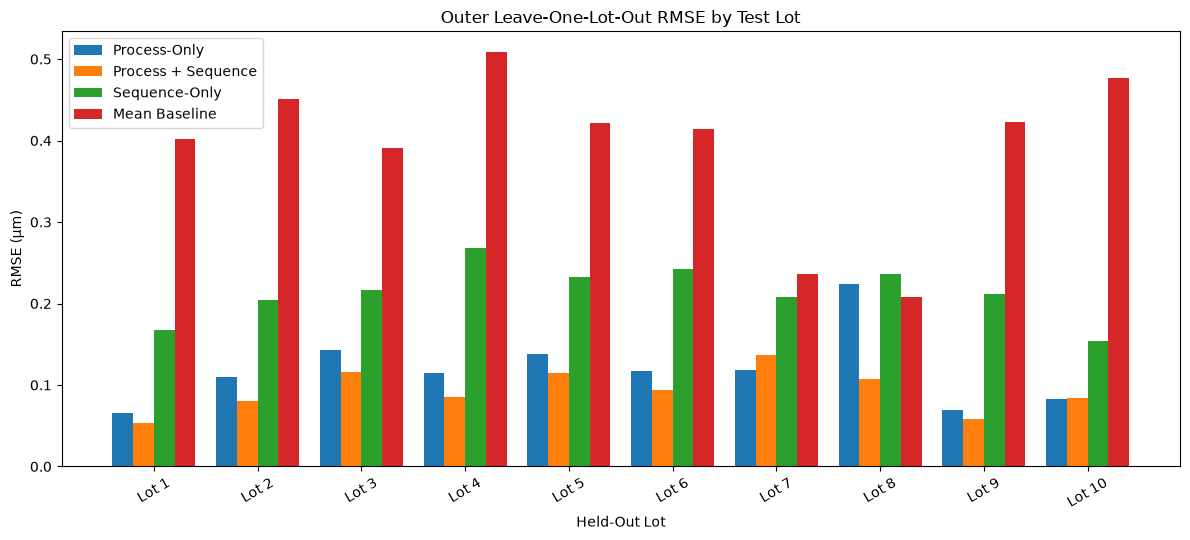

In [9]:
plot_folds = (
    ablation_lot_comparison
    .sort_values("test_lot")
    .reset_index(drop=True)
)

x = np.arange(
    len(plot_folds)
)

width = 0.20

plt.figure(
    figsize=(12, 5.5)
)

plt.bar(
    x - 1.5 * width,
    plot_folds[
        "process_only_rmse"
    ],
    width=width,
    label="Process-Only",
)

plt.bar(
    x - 0.5 * width,
    plot_folds[
        "process_plus_sequence_rmse"
    ],
    width=width,
    label="Process + Sequence",
)

plt.bar(
    x + 0.5 * width,
    plot_folds[
        "sequence_baseline_rmse"
    ],
    width=width,
    label="Sequence-Only",
)

plt.bar(
    x + 1.5 * width,
    plot_folds[
        "mean_baseline_rmse"
    ],
    width=width,
    label="Mean Baseline",
)

plt.xticks(
    x,
    [
        f"Lot {lot}"
        for lot in plot_folds[
            "test_lot"
        ]
    ],
    rotation=30,
)

plt.ylabel("RMSE (µm)")
plt.xlabel("Held-Out Lot")
plt.title(
    "Outer Leave-One-Lot-Out RMSE by Test Lot"
)
plt.legend()
plt.tight_layout()
plt.show()


### 6.5 這張圖的輸出代表什麼？

這張圖把每個 held-out Lot 的四種 RMSE 放在一起比較。

從實際數字看：

- `Process + Sequence` 在 **9 個 Lots** 的 bar 都比 `Process-Only` 低。
- 唯一例外是 **Lot 7**，Process + Sequence 是 **0.1371**，高於 Process-Only 的 **0.1184**。
- **Lot 8** 的差距很明顯，Process-Only 是 **0.2238**，加上 Sequence 後降到 **0.1071**。
- Lot 1 和 Lot 9 的 Process + Sequence RMSE 最低，分別是 **0.0538** 和 **0.0578**。

這張圖主要就是把上一張 Lot-level RMSE 表的差異視覺化，可以直接看到不同 Lots 的模型誤差並不一樣。


## 7. 固定 Model Family 後，再做一個 Candidate-Family Comparison

前面的 nested procedure 是「每個 outer fold 都可以自己選最佳 feature set + model + hyperparameters」。

這裡再多做一個比較，固定每個：

`Feature Set × Model Family`

然後只在 inner CV 裡選該 family 的 hyperparameters。

這樣可以比較 Base / Extended + Ridge / ElasticNet / PLS / SVR 各自的 pooled outer OOF performance。

但這張表是 **candidate comparison**。  
如果我看完這張表再挑第一名，第一名的 score 就不能再當作全新的 independent test score。正式 performance 還是以 Section 6 的 nested procedure 為主。


In [10]:
family_combinations = [
    (feature_set, model_name)
    for feature_set in ["Base", "Extended"]
    for model_name in ["Ridge", "ElasticNet", "PLS", "SVR"]
]

family_predictions = {
    f"{feature_set}__{model_name}": np.full(len(y), np.nan)
    for feature_set, model_name in family_combinations
}

family_fold_records = []

for outer_fold, (train_idx, test_idx) in enumerate(outer_splits, start=1):
    test_lot = int(np.unique(groups[test_idx])[0])

    for feature_set, model_name in family_combinations:
        family_inner = (
            inner_candidate_scores.loc[
                (inner_candidate_scores["outer_fold"] == outer_fold)
                & (inner_candidate_scores["feature_set"] == feature_set)
                & (inner_candidate_scores["model"] == model_name)
            ]
            .sort_values("inner_rmse")
            .iloc[0]
        )

        params = json.loads(family_inner["params"])
        estimator = build_estimator(model_name, params)
        estimator.fit(
            X_sets[feature_set][train_idx],
            y[train_idx],
        )

        pred = np.asarray(
            estimator.predict(X_sets[feature_set][test_idx])
        ).reshape(-1)

        family_predictions[f"{feature_set}__{model_name}"][test_idx] = pred

        family_fold_records.append(
            {
                "outer_fold": outer_fold,
                "test_lot": test_lot,
                "feature_set": feature_set,
                "model": model_name,
                "params": family_inner["params"],
                "inner_rmse": family_inner["inner_rmse"],
                "outer_rmse": float(mean_squared_error(y[test_idx], pred) ** 0.5),
                "outer_mae": float(mean_absolute_error(y[test_idx], pred)),
            }
        )

family_fold_results = pd.DataFrame(family_fold_records)

family_summary_records = []

for feature_set, model_name in family_combinations:
    pred = family_predictions[f"{feature_set}__{model_name}"]

    family_summary_records.append(
        {
            "feature_set": feature_set,
            "model": model_name,
            **regression_metrics(y, pred),
        }
    )

family_model_summary = (
    pd.DataFrame(family_summary_records)
    .sort_values("rmse")
    .reset_index(drop=True)
)

display(family_model_summary.round(4))


,feature_set,model,rmse,mae,r2
0,Extended,ElasticNet,0.1222,0.0908,0.9065
1,Base,ElasticNet,0.1347,0.1031,0.8864
2,Extended,Ridge,0.1589,0.1171,0.8419
3,Extended,PLS,0.1603,0.1192,0.8391
4,Base,Ridge,0.1635,0.1134,0.8326
5,Base,PLS,0.1864,0.1237,0.7825
6,Base,SVR,0.2130,0.1669,0.7160
7,Extended,SVR,0.2195,0.1781,0.6983


### 7.1 這個輸出代表什麼？

固定 Feature Set 和 Model Family 後，整體 RMSE 由低到高是：

1. Extended + ElasticNet：**0.1222**
2. Base + ElasticNet：**0.1347**
3. Extended + Ridge：**0.1589**
4. Extended + PLS：**0.1603**
5. Base + Ridge：**0.1635**
6. Base + PLS：**0.1864**
7. Base + SVR：**0.2130**
8. Extended + SVR：**0.2195**

這張表裡 RMSE 最低的是 **Extended + ElasticNet**，同時它的 MAE 也是最低的 **0.0908**，R² 最高 **0.9065**。

兩個 ElasticNet 組合排在前兩名，兩個 SVR 組合則排在最後兩名。

所以這一格顯示，在目前這組 held-out-Lot 結果中，ElasticNet family 的數字最好。


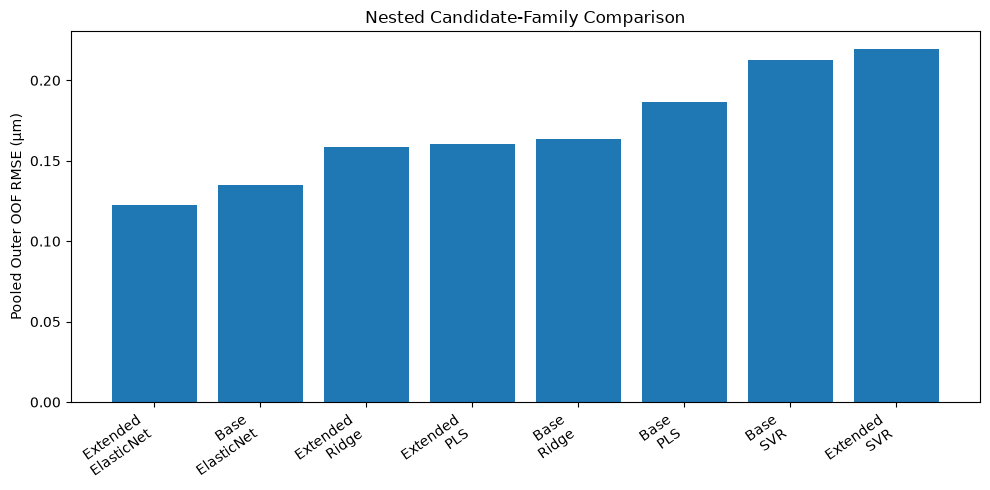

In [11]:
plt.figure(figsize=(10, 5))

plot_family = family_model_summary.copy()
labels = (
    plot_family["feature_set"]
    + "\n"
    + plot_family["model"]
)

plt.bar(
    np.arange(len(plot_family)),
    plot_family["rmse"],
)

plt.xticks(
    np.arange(len(plot_family)),
    labels,
    rotation=35,
    ha="right",
)

plt.ylabel("Pooled Outer OOF RMSE (µm)")
plt.title("Nested Candidate-Family Comparison")
plt.tight_layout()
plt.show()


### 7.2 這張圖的輸出代表什麼？

這張 bar chart 是把上一張 Family Summary 的 RMSE 畫出來。

圖上可以直接看到：

- 最低：Extended + ElasticNet = **0.1222**
- 第二低：Base + ElasticNet = **0.1347**
- 最高：Extended + SVR = **0.2195**

也就是 ElasticNet 的兩個 bars 最短，SVR 的兩個 bars 最長。

這張圖沒有新增新的數字，主要是把不同 Model Family 的 RMSE 差距更直觀地畫出來。


## 7.3 看每一片 Wafer 的 Nested OOF Error

Pooled RMSE 只能告訴我平均誤差多大，但不會告訴我「哪一片最難」。

所以這一步把每片 wafer 的：

- actual
- nested OOF prediction
- signed error
- absolute error

都保留下來。

這些 errors **不再拿來選模型**，而是交給 09 做 explainability，也可以和後面的 anomaly / OOD result 做交叉比對。


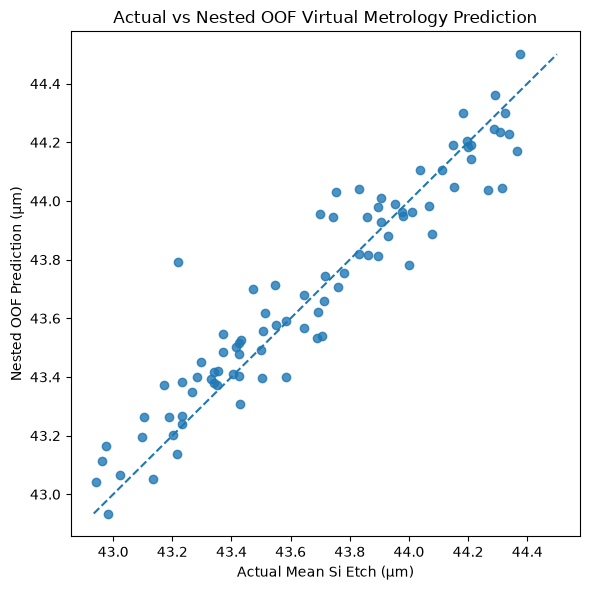

Largest Absolute Nested OOF Errors：


,experiment_key,lot_number,wafer_number,actual_mean_si_etch,nested_process_pred,nested_error,abs_nested_error
74,2024-08-07_10,8,10,43.2175,43.7931,0.5756,0.5756
49,2024-08-01_01,6,1,43.7522,44.0319,0.2796,0.2796
39,2024-07-19_01,5,1,44.3142,44.0441,-0.2701,0.2701
72,2024-08-07_08,8,8,43.6991,43.9566,0.2575,0.2575
21,2024-07-09_03,3,3,44.2660,44.0385,-0.2276,0.2276
73,2024-08-07_09,8,9,43.4738,43.6998,0.2260,0.2260
32,2024-07-11_04,4,4,43.9986,43.7801,-0.2185,0.2185
59,2024-08-05_01,7,1,43.8311,44.0397,0.2086,0.2086
65,2024-08-07_01,8,1,43.7445,43.9465,0.2020,0.2020
46,2024-07-19_08,5,8,43.1721,43.3724,0.2003,0.2003


In [12]:
nested_predictions = pd.DataFrame(
    {
        "experiment_key": experiment_keys,
        "lot_number": groups,
        "wafer_number": wafer_number.astype(int),
        "actual_mean_si_etch": y,
        "mean_baseline_pred": mean_baseline_pred,
        "sequence_baseline_pred": sequence_baseline_pred,
        "nested_process_pred": nested_oof_pred,
    }
)

nested_predictions["nested_error"] = (
    nested_predictions["nested_process_pred"]
    - nested_predictions["actual_mean_si_etch"]
)

nested_predictions["abs_nested_error"] = (
    nested_predictions["nested_error"].abs()
)

plt.figure(figsize=(6, 6))
plt.scatter(
    nested_predictions["actual_mean_si_etch"],
    nested_predictions["nested_process_pred"],
    alpha=0.8,
)

lower = min(
    nested_predictions["actual_mean_si_etch"].min(),
    nested_predictions["nested_process_pred"].min(),
)
upper = max(
    nested_predictions["actual_mean_si_etch"].max(),
    nested_predictions["nested_process_pred"].max(),
)

plt.plot([lower, upper], [lower, upper], linestyle="--")
plt.xlabel("Actual Mean Si Etch (µm)")
plt.ylabel("Nested OOF Prediction (µm)")
plt.title("Actual vs Nested OOF Virtual Metrology Prediction")
plt.tight_layout()
plt.show()

print("Largest Absolute Nested OOF Errors：")
display(
    nested_predictions
    .nlargest(10, "abs_nested_error")
    [
        [
            "experiment_key",
            "lot_number",
            "wafer_number",
            "actual_mean_si_etch",
            "nested_process_pred",
            "nested_error",
            "abs_nested_error",
        ]
    ]
    .round(4)
)


### 7.4 這個輸出代表什麼？

Actual vs Prediction 圖是把 88 片 wafer 的實際 `mean_si_etch` 和 Nested OOF prediction 畫在一起；虛線代表 prediction 和 actual 完全相同。

下面的表則列出 absolute error 最大的 10 片 wafers。

最大的一筆是：

`2024-08-07_10`

- Lot：**8**
- Wafer：**10**
- Actual：**43.2175**
- Prediction：**43.7931**
- Error：**+0.5756**
- Absolute Error：**0.5756**

第二大的 absolute error 是 **0.2796**，所以第一大的 **0.5756** 明顯高出一截。

前 10 大 absolute errors 裡，Lot 8 一共有 **4 片**：

- `2024-08-07_10`
- `2024-08-07_08`
- `2024-08-07_09`
- `2024-08-07_01`

其餘則分散在 Lot 3、4、5、6、7。

所以這個輸出顯示，整體 RMSE 雖然是 0.1296，但少數 wafers 的 prediction error 會明顯大很多。


## 8. Nested Evaluation 做完後，再建立 Final Prototype Model

前面的 nested outer evaluation 已經先完成，所以現在才使用全部 88 片 labeled wafers 來選一個 final configuration。

這個 final model 的用途是：

- 09 explainability
- prototype / deployment preparation

做法是用全部 10 Lots 的 grouped LOGO CV 比較同一批 36 candidates，選 grouped CV RMSE 最低的 configuration，再用全部 88 片 fit 最後一個 pipeline。

要注意：

> **這裡的 selection score 不是新的 independent test performance。**

因為我已經用全部資料參與 final configuration selection。  
真正要報 generalization 時，還是回到前面的 nested OOF metrics。


In [13]:
full_selection_records = []

for feature_set, model_name, params in candidate_configs:
    full_oof = np.full(len(y), np.nan)
    estimator = build_estimator(model_name, params)

    for train_idx, valid_idx in outer_splits:
        fitted = clone(estimator)
        fitted.fit(
            X_sets[feature_set][train_idx],
            y[train_idx],
        )
        full_oof[valid_idx] = np.asarray(
            fitted.predict(X_sets[feature_set][valid_idx])
        ).reshape(-1)

    full_selection_records.append(
        {
            "feature_set": feature_set,
            "model": model_name,
            "params": json.dumps(params, sort_keys=True),
            "logo_rmse": float(mean_squared_error(y, full_oof) ** 0.5),
        }
    )

full_selection_scores = (
    pd.DataFrame(full_selection_records)
    .sort_values("logo_rmse")
    .reset_index(drop=True)
)

display(full_selection_scores.head(10).round(5))

best_full = full_selection_scores.iloc[0]
final_feature_set = best_full["feature_set"]
final_model_name = best_full["model"]
final_params = json.loads(best_full["params"])

print("Final Feature Set：", final_feature_set)
print("Final Model：", final_model_name)
print("Final Params：", final_params)


,feature_set,model,params,logo_rmse
0,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.1}",0.11121
1,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.5}",0.11173
2,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",0.11869
3,Base,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.5}",0.12930
4,Base,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.1}",0.12997
5,Extended,ElasticNet,"{""alpha"": 0.1, ""l1_ratio"": 0.1}",0.13321
6,Base,Ridge,"{""alpha"": 1}",0.13338
7,Base,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",0.13644
8,Extended,Ridge,"{""alpha"": 1}",0.13853
9,Extended,Ridge,"{""alpha"": 10}",0.14229


Final Feature Set： Extended
Final Model： ElasticNet
Final Params： {'alpha': 0.01, 'l1_ratio': 0.1}


### 8.1 這個輸出代表什麼？

Full-data grouped LOGO selection 的前幾名幾乎都是 ElasticNet。

前三名是：

1. Extended + ElasticNet  
   `alpha = 0.01`、`l1_ratio = 0.1`  
   LOGO RMSE = **0.11121**

2. Extended + ElasticNet  
   `alpha = 0.01`、`l1_ratio = 0.5`  
   LOGO RMSE = **0.11173**

3. Extended + ElasticNet  
   `alpha = 0.01`、`l1_ratio = 0.9`  
   LOGO RMSE = **0.11869**

第一名和第二名只差 **0.00052 RMSE**。

最後選到的是：

- Feature Set：**Extended**
- Model：**ElasticNet**
- `alpha = 0.01`
- `l1_ratio = 0.1`

所以這格就是把 final prototype 最後採用的設定選出來。


In [14]:
final_estimator = build_estimator(final_model_name, final_params)
final_estimator.fit(
    X_sets[final_feature_set],
    y,
)

# Recover the columns retained by the same near-constant rule used in CV.
variance_mask = final_estimator.named_steps["variance"].get_support()
final_kept_features = np.asarray(
    predictor_names[final_feature_set]
)[variance_mask]

final_model = final_estimator.named_steps["model"]

# Only Ridge / ElasticNet have coefficients that can be interpreted directly
# after the explicit StandardScaler step used in this pipeline.
linear_coefficients_available = final_model_name in {"Ridge", "ElasticNet"}

coefficient_columns = [
    "feature",
    "coefficient_standardized",
    "abs_coefficient",
]

if linear_coefficients_available:
    model_coefficients = np.asarray(final_model.coef_, dtype=float).reshape(-1)

    if len(model_coefficients) != len(final_kept_features):
        raise ValueError(
            "Final linear coefficient count 與 variance-filter 後 predictors 不一致"
        )

    final_coefficients = (
        pd.DataFrame(
            {
                "feature": final_kept_features,
                "coefficient_standardized": model_coefficients,
                "abs_coefficient": np.abs(model_coefficients),
            }
        )
        .sort_values("abs_coefficient", ascending=False)
        .reset_index(drop=True)
    )

    n_nonzero = int(np.count_nonzero(np.abs(model_coefficients) > 1e-12))
else:
    # Keep a stable schema even when the selected model has no direct
    # standardized linear coefficients (e.g. PLS / RBF-SVR here).
    final_coefficients = pd.DataFrame(columns=coefficient_columns)
    n_nonzero = None

print("Final Training Wafers：", len(y))
print("Final Feature Set：", final_feature_set)
print("Final Model：", final_model_name)
print("Input Predictors：", len(predictor_names[final_feature_set]))
print("Predictors after Near-Constant Filter：", len(final_kept_features))
print("Direct Linear Coefficients Available：", linear_coefficients_available)
print("Non-zero Linear Coefficients：", n_nonzero)

if linear_coefficients_available:
    print("\nTop standardized coefficients — descriptive only：")
    display(final_coefficients.head(15).round(5))
else:
    print(
        "\nSelected model沒有可直接作 standardized additive interpretation 的"
        " Ridge / ElasticNet coefficients；09 將改用 model-agnostic permutation / local sensitivity。"
    )


Final Training Wafers： 88
Final Feature Set： Extended
Final Model： ElasticNet
Input Predictors： 109
Predictors after Near-Constant Filter： 98
Direct Linear Coefficients Available： True
Non-zero Linear Coefficients： 54

Top standardized coefficients — descriptive only：


,feature,coefficient_standardized,abs_coefficient
0,robust_width__PlatenRFTuningCapacitor,0.15959,0.15959
1,mean__PlatenRFTuningCapacitor,-0.10487,0.10487
2,main_active_duration,0.09182,0.09182
3,robust_width__PlatenRFReflectedPower,-0.09083,0.09083
4,std__ForeLinePressure,-0.07588,0.07588
5,mean__Heater2Temp,0.05977,0.05977
6,std__SourceRFReflectedPower,-0.05684,0.05684
7,mean__SourceRFLoadPower,0.04794,0.04794
8,std__SourceRFPeakToPeak,0.04177,0.04177
9,late_minus_early__PlatenRFLoadCapacitor,-0.03816,0.03816


### 8.2 這個輸出代表什麼？

Final model 使用：

- Training Wafers：**88**
- Feature Set：**Extended**
- Model：**ElasticNet**
- Input Predictors：**109**

Near-Constant Filter 後剩：

- **98 個 predictors**

也就是有 **11 個 predictors** 在這一步被 filter 掉。

98 個保留下來的 predictors 裡：

- Non-zero coefficients：**54**

所以另外 **44 個 coefficients 是 0**。

按 absolute coefficient 排名前三的是：

1. `robust_width__PlatenRFTuningCapacitor`：**+0.15959**
2. `mean__PlatenRFTuningCapacitor`：**-0.10487**
3. `main_active_duration`：**+0.09182**

這張表顯示的是 final ElasticNet fitted model 裡的 standardized coefficients 大小和正負方向。


## 9. 把 Modeling 結果和 Final Pipeline 存下來

這一格會保留原本 08 的輸出，另外加入 Process + Sequence Ablation 的四份 CSV：

- `08_ablation_metrics.csv`
- `08_ablation_inner_candidate_scores.csv`
- `08_process_plus_sequence_outer_fold_results.csv`
- `08_ablation_oof_predictions.csv`

原本 09 / 10 會使用的：

- `08_nested_oof_predictions.csv`
- `08_final_model_config.json`
- `08_final_virtual_metrology_model.joblib`

檔名和原本 schema 都不改。


In [15]:
baseline_metrics_path = (
    PROCESSED_DATA_DIR
    / "08_baseline_metrics.csv"
)

outer_results_path = (
    PROCESSED_DATA_DIR
    / "08_nested_outer_fold_results.csv"
)

inner_scores_path = (
    PROCESSED_DATA_DIR
    / "08_nested_inner_candidate_scores.csv"
)

nested_predictions_path = (
    PROCESSED_DATA_DIR
    / "08_nested_oof_predictions.csv"
)

family_summary_path = (
    PROCESSED_DATA_DIR
    / "08_family_model_summary.csv"
)

family_fold_path = (
    PROCESSED_DATA_DIR
    / "08_family_fold_results.csv"
)

full_selection_path = (
    PROCESSED_DATA_DIR
    / "08_full_selection_scores.csv"
)

coefficients_path = (
    PROCESSED_DATA_DIR
    / "08_final_model_coefficients.csv"
)

ablation_metrics_path = (
    PROCESSED_DATA_DIR
    / "08_ablation_metrics.csv"
)

ablation_inner_scores_path = (
    PROCESSED_DATA_DIR
    / "08_ablation_inner_candidate_scores.csv"
)

ablation_outer_results_path = (
    PROCESSED_DATA_DIR
    / "08_process_plus_sequence_outer_fold_results.csv"
)

ablation_predictions_path = (
    PROCESSED_DATA_DIR
    / "08_ablation_oof_predictions.csv"
)

final_config_path = (
    PROCESSED_DATA_DIR
    / "08_final_model_config.json"
)

final_model_path = (
    MODEL_DIR
    / "08_final_virtual_metrology_model.joblib"
)

baseline_metrics.to_csv(
    baseline_metrics_path,
    index=False,
)

outer_fold_results.to_csv(
    outer_results_path,
    index=False,
)

inner_candidate_scores.to_csv(
    inner_scores_path,
    index=False,
)

nested_predictions.to_csv(
    nested_predictions_path,
    index=False,
)

family_model_summary.to_csv(
    family_summary_path,
    index=False,
)

family_fold_results.to_csv(
    family_fold_path,
    index=False,
)

full_selection_scores.to_csv(
    full_selection_path,
    index=False,
)

final_coefficients.to_csv(
    coefficients_path,
    index=False,
)

ablation_metrics.to_csv(
    ablation_metrics_path,
    index=False,
)

ablation_inner_candidate_scores.to_csv(
    ablation_inner_scores_path,
    index=False,
)

process_plus_sequence_outer_results.to_csv(
    ablation_outer_results_path,
    index=False,
)

ablation_predictions.to_csv(
    ablation_predictions_path,
    index=False,
)

final_config = {
    "target": "mean_si_etch",
    "feature_set": final_feature_set,
    "model": final_model_name,
    "params": final_params,
    "n_training_wafers": int(len(y)),
    "n_input_predictors": int(
        len(
            predictor_names[
                final_feature_set
            ]
        )
    ),
    "input_predictors_in_order": list(
        predictor_names[
            final_feature_set
        ]
    ),
    "n_predictors_after_variance_filter": int(
        len(final_kept_features)
    ),
    "predictors_after_variance_filter": (
        final_kept_features.tolist()
    ),
    "linear_coefficients_available": bool(
        linear_coefficients_available
    ),
    "n_nonzero_coefficients": (
        int(n_nonzero)
        if n_nonzero is not None
        else None
    ),
    "full_data_selection_logo_rmse": float(
        best_full["logo_rmse"]
    ),
    "primary_evaluation": (
        "Nested Leave-One-Lot-Out outer validation"
    ),
    "performance_note": (
        "Use nested outer OOF metrics for internal "
        "generalization evidence; the final full-data "
        "fit has no independent test score."
    ),
    "sequence_ablation_note": (
        "wafer_number is excluded from the primary "
        "Process-only model and used only in the "
        "Sequence-only baseline and the separate "
        "Process + Sequence nested ablation."
    ),
    "explainability_note": (
        "Direct standardized coefficients are exported "
        "only for Ridge / ElasticNet. Other selected "
        "model families require model-agnostic "
        "explainability in 09."
    ),
}

with open(
    final_config_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        final_config,
        file,
        ensure_ascii=False,
        indent=2,
    )

joblib.dump(
    final_estimator,
    final_model_path,
)

csv_artifacts = {
    baseline_metrics_path:
        baseline_metrics,
    outer_results_path:
        outer_fold_results,
    inner_scores_path:
        inner_candidate_scores,
    nested_predictions_path:
        nested_predictions,
    family_summary_path:
        family_model_summary,
    family_fold_path:
        family_fold_results,
    full_selection_path:
        full_selection_scores,
    coefficients_path:
        final_coefficients,
    ablation_metrics_path:
        ablation_metrics,
    ablation_inner_scores_path:
        ablation_inner_candidate_scores,
    ablation_outer_results_path:
        process_plus_sequence_outer_results,
    ablation_predictions_path:
        ablation_predictions,
}

validation_records = []

for path, expected_df in csv_artifacts.items():
    reloaded = pd.read_csv(
        path
    )

    same_rows = (
        len(reloaded)
        == len(expected_df)
    )

    same_columns = (
        list(reloaded.columns)
        == list(expected_df.columns)
    )

    if (
        not same_rows
        or not same_columns
    ):
        raise ValueError(
            "Artifact read-back validation failed: "
            f"{path.name}"
        )

    validation_records.append(
        {
            "artifact": path.name,
            "rows": len(reloaded),
            "schema_match": same_columns,
        }
    )

with open(
    final_config_path,
    "r",
    encoding="utf-8",
) as file:
    config_check = json.load(
        file
    )

if config_check != final_config:
    raise ValueError(
        "Final config JSON read-back 不一致"
    )

reloaded_estimator = joblib.load(
    final_model_path
)

original_full_pred = np.asarray(
    final_estimator.predict(
        X_sets[
            final_feature_set
        ]
    )
).reshape(-1)

reloaded_full_pred = np.asarray(
    reloaded_estimator.predict(
        X_sets[
            final_feature_set
        ]
    )
).reshape(-1)

if not np.allclose(
    original_full_pred,
    reloaded_full_pred,
    rtol=0,
    atol=1e-12,
):
    raise ValueError(
        "Reloaded final model predictions 與原 model 不一致"
    )

artifact_validation = pd.DataFrame(
    validation_records
)

print(
    "CSV Read-Back Validation："
)
display(
    artifact_validation
)

print(
    "JSON Read-Back：通過"
)

print(
    "Joblib Prediction Read-Back：通過"
)


CSV Read-Back Validation：


,artifact,rows,schema_match
0,08_baseline_metrics.csv,2,True
1,08_nested_outer_fold_results.csv,10,True
2,08_nested_inner_candidate_scores.csv,360,True
3,08_nested_oof_predictions.csv,88,True
4,08_family_model_summary.csv,8,True
5,08_family_fold_results.csv,80,True
6,08_full_selection_scores.csv,36,True
7,08_final_model_coefficients.csv,98,True
8,08_ablation_metrics.csv,4,True
9,08_ablation_inner_candidate_scores.csv,360,True


JSON Read-Back：通過
Joblib Prediction Read-Back：通過


### 9.1 這個輸出代表什麼？

最後一共檢查 **12 個 CSV artifacts**。

實際 row 數是：

- `08_baseline_metrics.csv`：2
- `08_nested_outer_fold_results.csv`：10
- `08_nested_inner_candidate_scores.csv`：360
- `08_nested_oof_predictions.csv`：88
- `08_family_model_summary.csv`：8
- `08_family_fold_results.csv`：80
- `08_full_selection_scores.csv`：36
- `08_final_model_coefficients.csv`：98
- `08_ablation_metrics.csv`：4
- `08_ablation_inner_candidate_scores.csv`：360
- `08_process_plus_sequence_outer_fold_results.csv`：10
- `08_ablation_oof_predictions.csv`：88

12 個檔案的：

`schema_match`

全部都是 **True**。

最後也顯示：

- `JSON Read-Back：通過`
- `Joblib Prediction Read-Back：通過`

所以這格實際確認的是：08 的 CSV、JSON 和儲存後重新載入的 final model 都成功通過檢查。


# 08｜實際輸出結果整理

這份 08 最後跑出的主要結果可以整理成：

### Baseline

- Training-Mean RMSE：**0.4044**
- Sequence-Only RMSE：**0.2209**

Sequence-Only 比 Training-Mean 的 RMSE 大約低 **45.4%**。

### Process-Only Nested Model

- RMSE：**0.1296**
- MAE：**0.0972**
- R²：**0.8948**

它的 RMSE 比 Sequence-Only 再低大約 **41.3%**。

10 個 outer folds 全部選到 **ElasticNet**：

- Extended：6 次
- Base：4 次

### Process + Sequence Ablation

- RMSE：**0.0954**
- MAE：**0.0750**
- R²：**0.9430**

和 Process-Only 比：

- RMSE：**0.1296 → 0.0954**
- 大約低 **26.4%**

10 個 Lots 裡有 **9 個** RMSE 下降，只有 Lot 7 變高：

- Process-Only：0.1184
- Process + Sequence：0.1371

Process + Sequence 的 10 個 outer folds：

- **10/10 都選 ElasticNet**
- **10/10 都選 Base**

### Lot-level 差異

Process-Only：

- 最低 RMSE：Lot 1 = **0.0652**
- 最高 RMSE：Lot 8 = **0.2238**

Process + Sequence：

- Lot 8：**0.1071**
- Lot 1：**0.0538**
- Lot 9：**0.0578**

### Family Comparison

RMSE 最低的是：

- Extended + ElasticNet = **0.1222**

最高的是：

- Extended + SVR = **0.2195**

### 最大單片 OOF Error

`2024-08-07_10`

- Absolute Error：**0.5756**

前 10 大 absolute errors 裡有 **4 片**來自 Lot 8。

### Final Prototype

最後選到：

- Feature Set：**Extended**
- Model：**ElasticNet**
- `alpha = 0.01`
- `l1_ratio = 0.1`

109 個 input predictors 經 Near-Constant Filter 後剩 **98 個**，其中 **54 個 coefficients 非 0**。

### 輸出檔案

最後檢查 **12 個 CSV artifacts**，全部 `schema_match = True`。

另外：

- JSON Read-Back：通過
- Joblib Prediction Read-Back：通過

這些都是這份 Notebook 實際跑出的結果，沒有另外加入 Output 沒有顯示的製程原因或因果解讀。
